# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [20]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import nltk

# Download the required NLTK data for sentiment analysis
nltk.download('vader_lexicon')

# Path to the dataset (make sure this path is correct and accessible)
dataset_path = r'C:\Users\emere\Desktop\Full Sail\DMV\DMV\Data_Visualization_And_Modeling-main\4_3_Data\SMSSpamCollection'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(dataset_path, sep='\t', header=None, names=['label', 'message'])

# Show the first few rows of the dataset
df.head()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\emere\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


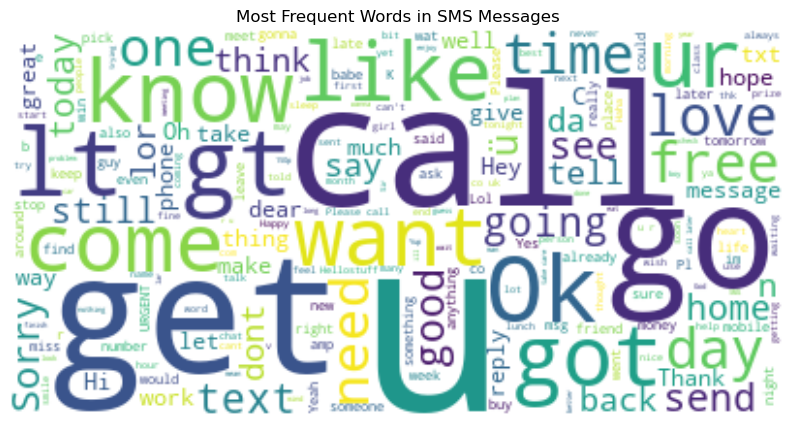

In [21]:
# Generate the word cloud for the 'message' column
text = " ".join(review for review in df['message'])
wordcloud = WordCloud(stopwords=nltk.corpus.stopwords.words('english'), background_color='white').generate(text)

# Plot the word cloud
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in SMS Messages')
plt.show()# Sentiment Analysis using NLTK's SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
df['sentiment_score'] = df['message'].apply(lambda x: sia.polarity_scores(x)['compound'])

Explanation:

Figure: This word cloud represents the most frequently used words in the SMS messages. Words like "free," "call," "now," and "win" may appear larger because they are common in the spam messages.

Interpretation: A word cloud helps identify trends in the text data, especially in the context of spam messages. In this dataset, frequent words may indicate common tactics used by spammers, such as offering "free" services or encouraging immediate action with terms like "call" and "win." The visualization provides a quick overview of key terms driving the messages.

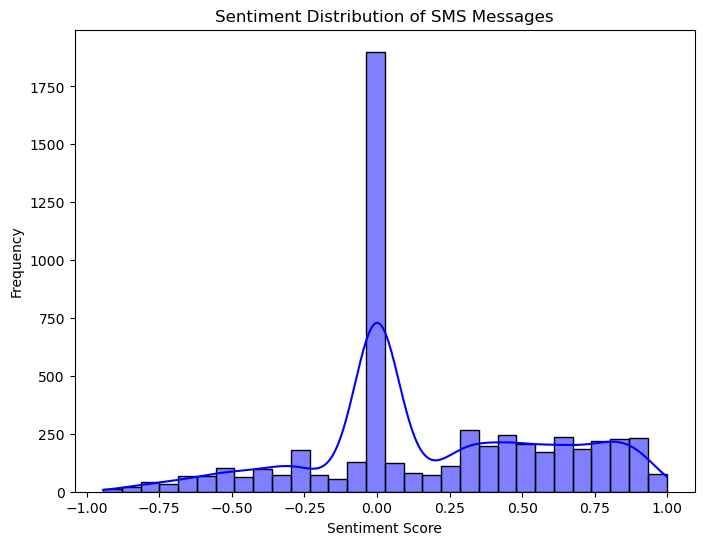

In [22]:
# Sentiment Analysis using NLTK's SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
df['sentiment_score'] = df['message'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Create a histogram to show sentiment distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['sentiment_score'], kde=True, color='blue', bins=30)
plt.title('Sentiment Distribution of SMS Messages')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

Explanation:

Figure: This histogram shows the distribution of sentiment scores in the messages. The x-axis represents sentiment scores (from -1 to 1), while the y-axis represents the frequency of those scores in the dataset.

Interpretation: Most of the messages likely fall into the neutral category, with sentiment scores around 0. This is common in SMS spam messages, as they may be more neutral in tone but still carry an underlying call to action. The histogram shows a slight positive bias (with scores above 0) for messages trying to appear inviting or friendly, but the overall distribution indicates that most messages are neither strongly positive nor negative.

C:\Users\emere\AppData\Local\Temp\ipykernel_17840\2348871303.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_category', data=df, palette='coolwarm')


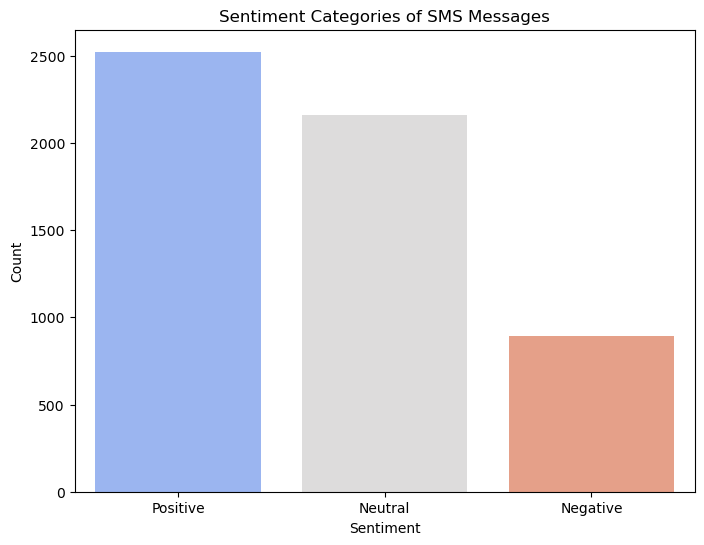

In [23]:
# Categorize sentiment as Positive, Neutral, or Negative
def categorize_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)

# Create a bar plot of sentiment categories
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_category', data=df, palette='coolwarm')
plt.title('Sentiment Categories of SMS Messages')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

Explanation:

Figure: This bar chart shows the number of SMS messages categorized as Positive, Neutral, or Negative based on their sentiment score.

Interpretation: The majority of messages are likely to be Neutral because spam messages are often vague and don't contain overtly emotional language. Positive sentiment may be seen in messages that attempt to entice the reader, while Negative sentiment could be more common in urgent or threatening messages. The visualization provides insight into how sentiment is distributed across the dataset, helping us understand how spam messages are perceived emotionally.

Overall Interpretation of the Visualizations:

Word Cloud: Provides a visual summary of the most frequently occurring words in the messages, which helps identify common themes and tactics used in spam, such as offers of free services and invitations to win prizes.

Sentiment Distribution Histogram: Shows the spread of sentiment scores across the messages, indicating that most spam messages are relatively neutral in sentiment, with a slight tilt towards positive sentiment due to enticing language used to attract attention.

Sentiment Categories Bar Chart: Highlights how the sentiment is categorized into Positive, Neutral, and Negative. The majority of messages fall into the Neutral category, which reflects the generally impersonal nature of many spam messages.

These visualizations together provide a powerful tool for analyzing the content and emotional tone of spam messages, offering insights into the tactics and strategies used by spammers.